Import des bibliothèques necessaires

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

Chargement du dataset

In [3]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education',
    'education_num', 'marital_status', 'occupation',
    'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

df = pd.read_csv(
    '../data/adult.data',
    names=columns,
    sep=', ',
    engine='python'
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Exploration du dataset

Affichage d'informations

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Valeurs manquantes

In [5]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Taille du dataset

In [6]:
df.shape

(32561, 15)

Visualisation

Distribution des revenus

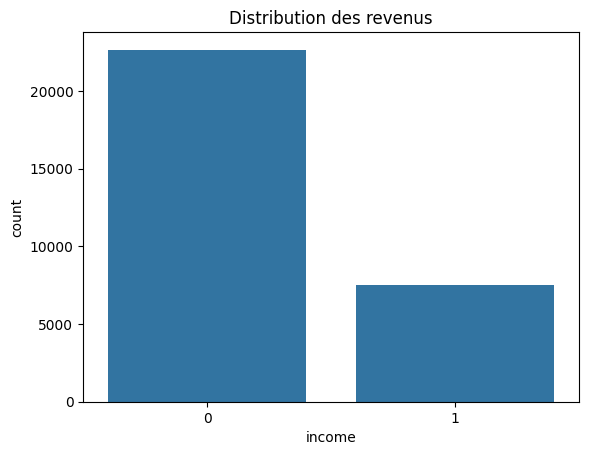

In [24]:
sns.countplot(x='income', data=df)
plt.title("Distribution des revenus")

plt.savefig('../images/income_distribution.png')
plt.show()

Distribution de l'âge

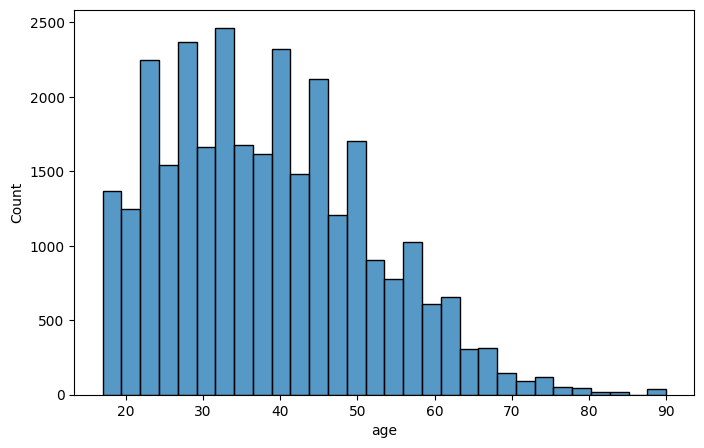

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30)

plt.savefig('../images/age_distribution.png')
plt.show()

Heures de travail

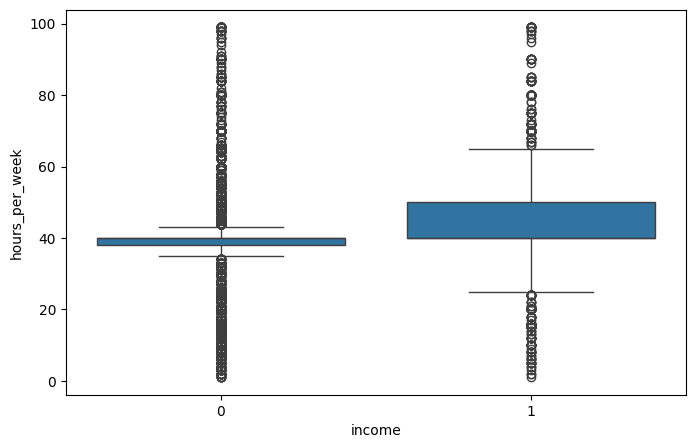

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='income', y='hours_per_week', data=df)
plt.savefig('../images/Heures_travail.png')
plt.show()

Prétraitement

Remplacement des ?

In [10]:
df.replace('?', np.nan, inplace=True)

Suppression des valeurs nulles

In [11]:
df.dropna(inplace=True)

Encodage des colonnes catégorielles

In [12]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

Séparation de X et y

In [13]:
X = df.drop('income', axis=1)
y = df['income']

Normalisation

In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Train/Test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Modèle 1 : KNN

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy KNN :", accuracy_score(y_test, y_pred_knn))

Accuracy KNN : 0.8257914801922758


Modèle 2 : Decision Tree

In [17]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy Decision Tree :", accuracy_score(y_test, y_pred_dt))

Accuracy Decision Tree : 0.8093817337974474


Modèle 3 : Logistic Regression

In [18]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy Logistic Regression :", accuracy_score(y_test, y_pred_lr))

Accuracy Logistic Regression : 0.823139399966849


Modèle 4 : Random Forest

In [19]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy Random Forest :", accuracy_score(y_test, y_pred_rf))

Accuracy Random Forest : 0.8564561577987734


Comparaison des modèles

In [20]:
results = pd.DataFrame({
    'Model': [
        'KNN',
        'Decision Tree',
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,KNN,0.825791
1,Decision Tree,0.809382
2,Logistic Regression,0.823139
3,Random Forest,0.856456


Matrice de confusion

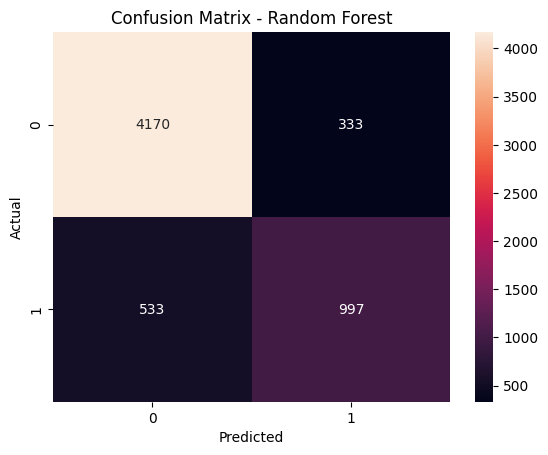

In [26]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('../images/confusion_matrix_rf.png')

plt.show()

Rapport détaillé

In [22]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4503
           1       0.75      0.65      0.70      1530

    accuracy                           0.86      6033
   macro avg       0.82      0.79      0.80      6033
weighted avg       0.85      0.86      0.85      6033



Importance des variables

In [23]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': df.drop('income', axis=1).columns,
    'Importance': importance
})

feature_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
2,fnlwgt,0.170767
0,age,0.153783
10,capital_gain,0.116883
7,relationship,0.103319
4,education_num,0.088492
12,hours_per_week,0.080653
6,occupation,0.068202
5,marital_status,0.066871
1,workclass,0.039605
11,capital_loss,0.034043


Graphique comparaison modèles

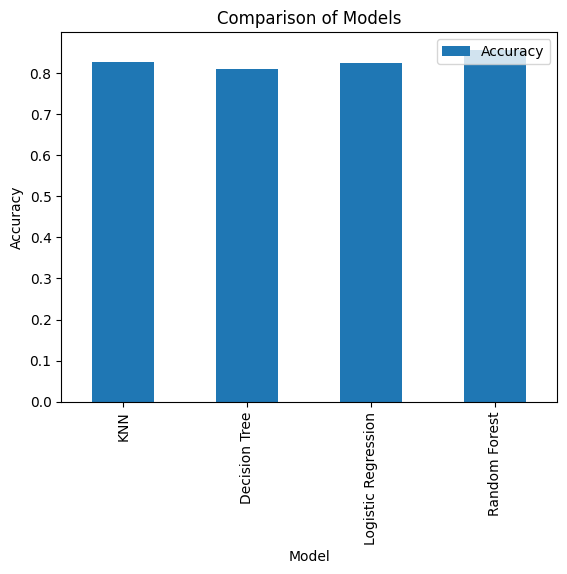

In [29]:
results.set_index('Model').plot(kind='bar')
plt.title("Comparison of Models")
plt.ylabel("Accuracy")
plt.savefig('../images/model_comparison.png')
plt.show()

Feature importance (Random Forest)

In [30]:
importances = rf.feature_importances_

features = pd.DataFrame({
    'Feature': df.drop('income', axis=1).columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

features

,Feature,Importance
2,fnlwgt,0.170767
0,age,0.153783
10,capital_gain,0.116883
7,relationship,0.103319
4,education_num,0.088492
12,hours_per_week,0.080653
6,occupation,0.068202
5,marital_status,0.066871
1,workclass,0.039605
11,capital_loss,0.034043
